In [1]:
# import all necessary libraries

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
from torch import nn
import torchvision
import numpy as np

import matplotlib.pyplot as plt
print(torch.__version__)

1.10.0


In [2]:
device_number = 3
device = torch.device(f"cuda:{device_number}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:3


In [3]:
# Load the saved data from .pt files
# These files contain the BEV embeddings for images and point clouds from mini_nuscenes dataset generated through UniBEV model
all_img = torch.load('/home/mingdayang/mmdetection3d/mapping_test/mini_nuscenes_LC_data/all_img_bev.pt')
all_pts = torch.load('/home/mingdayang/mmdetection3d/mapping_test/mini_nuscenes_LC_data/all_pts_bev.pt')

print("all_img shape:", all_img["img_bev_embed"].shape, "all_pts shape:", all_pts["pts_bev_embed"].shape)
print("all_img dtype:", all_img["img_bev_embed"].dtype, "all_pts dtype:", all_pts["pts_bev_embed"].dtype)
print("all_img keys:", all_img.keys(), "all_pts keys:", all_pts.keys())
print("all_img device:", all_img["img_bev_embed"].device, "all_pts device:", all_pts["pts_bev_embed"].device)

all_img shape: torch.Size([81, 1, 40000, 256]) all_pts shape: torch.Size([81, 1, 40000, 256])
all_img dtype: torch.float32 all_pts dtype: torch.float32
all_img keys: dict_keys(['img_bev_embed', 'lidar_file_name']) all_pts keys: dict_keys(['pts_bev_embed', 'lidar_file_name'])
all_img device: cpu all_pts device: cpu


In [56]:
img_bev_embed = all_img["img_bev_embed"].squeeze(1)
pts_bev_embed = all_pts["pts_bev_embed"].squeeze(1)

In [79]:
# Define helper function to go between data formats
# from [Batch, Channels, Height, Width] to [Batch, Values, Channels]

def bvc_to_bchw(tensor):
    B, V, C = tensor.shape
    tensor = tensor.reshape(-1, 200, 200, C)
    tensor = tensor.permute(0, 3, 2, 1).contiguous()
    return tensor

def bchw_to_bvc(tensor):
    B, C, H, W = tensor.shape
    tensor = tensor.reshape(B, C, H*W)
    tensor = tensor.permute(0, 2, 1).contiguous()  
    return tensor



In [80]:
# Test functions are working correctly
all_img_bev_shape = bvc_to_bchw(img_bev_embed)
print(all_img_bev_shape.shape)

all_img_flat_features = bchw_to_bvc(all_img_bev_shape)
all_img_flat_features.shape

torch.Size([81, 256, 200, 200])


torch.Size([81, 40000, 256])

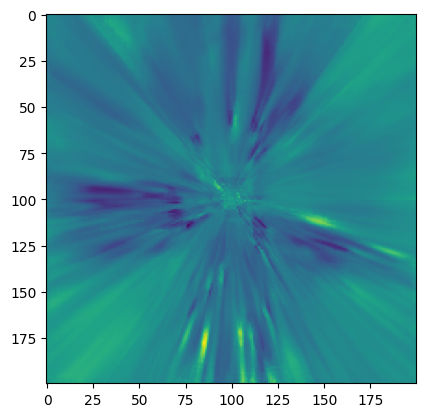

In [77]:
# visualize one channel to confirm it is loaded correctly
plt.imshow(all_img_bev_shape[6, 0].cpu().numpy())

In [44]:
#Load the model we want to visualize
import mmdet
from mmdet.models import HEADS

# Import to trigger registration (but catch any double registration errors)
try:
    from projects.UniBEV.unibev_plugin.models.dense_heads import bev_consumer
except KeyError:
    pass  # Already registered, which is fine

model = 'UnetFeatureMapping3layers'

# Now access the class from the registry
UnetFeatureMapping3layers = HEADS.get(model)

In [46]:
# Load the checkpoint where the model is stored
output_path = '/home/mingdayang/mmdetection3d/outputs/train/'
project_name = 'unibev_nus_LC_cnw_256_modality_dropout_freeze_unibev_train_auxiliary_unetfeaturemapping3layers'
checkpoint_name = 'latest.pth'
output_dir = os.path.join(output_path, project_name, checkpoint_name)
print(output_dir)

/home/mingdayang/mmdetection3d/outputs/train/unibev_nus_LC_cnw_256_modality_dropout_freeze_unibev_train_auxiliary_unetfeaturemapping3layers/latest.pth


In [47]:
#extract the model state dict 
checkpoint = torch.load(output_dir)

bev_consumer_state_dict = {}
prefix = "pts_bbox_head.bev_consumer."

for key in checkpoint['state_dict'].keys():
    if key.startswith(prefix):
        # Remove the prefix to get the model's parameter name
        new_key = key[len(prefix):]
        bev_consumer_state_dict[new_key] = checkpoint['state_dict'][key]

print(f"Extracted {len(bev_consumer_state_dict)} parameters:")
for key, value in bev_consumer_state_dict.items():
    print(f"  {key}: {value.shape}")

Extracted 76 parameters:
  enc1.0.weight: torch.Size([512, 256, 3, 3])
  enc1.0.bias: torch.Size([512])
  enc1.1.weight: torch.Size([512])
  enc1.1.bias: torch.Size([512])
  enc1.1.running_mean: torch.Size([512])
  enc1.1.running_var: torch.Size([512])
  enc1.1.num_batches_tracked: torch.Size([])
  enc1.3.weight: torch.Size([512, 512, 3, 3])
  enc1.3.bias: torch.Size([512])
  enc1.4.weight: torch.Size([512])
  enc1.4.bias: torch.Size([512])
  enc1.4.running_mean: torch.Size([512])
  enc1.4.running_var: torch.Size([512])
  enc1.4.num_batches_tracked: torch.Size([])
  enc2.0.weight: torch.Size([1024, 512, 3, 3])
  enc2.0.bias: torch.Size([1024])
  enc2.1.weight: torch.Size([1024])
  enc2.1.bias: torch.Size([1024])
  enc2.1.running_mean: torch.Size([1024])
  enc2.1.running_var: torch.Size([1024])
  enc2.1.num_batches_tracked: torch.Size([])
  enc2.3.weight: torch.Size([1024, 1024, 3, 3])
  enc2.3.bias: torch.Size([1024])
  enc2.4.weight: torch.Size([1024])
  enc2.4.bias: torch.Size([1024]

In [49]:
# Load the extracted state dict into the model
model_instance = UnetFeatureMapping3layers(input_channels=256, output_channels=256).to(device)
model_instance.load_state_dict(bev_consumer_state_dict)

<All keys matched successfully>

In [51]:
model_instance.eval()

UnetFeatureMapping3layers(
  (loss_fn): L1Loss()
  (enc1): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(1024, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_

In [64]:
from torch.utils.data import DataLoader, TensorDataset

BATCH_INFER = 4  # pick a size that fits memory

infer_loader = DataLoader(
    TensorDataset(img_bev_embed),
    batch_size=BATCH_INFER,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

pred_chunks = []
with torch.inference_mode():
    for (xb,) in infer_loader:
        xb = xb.to(device, non_blocking=True).contiguous()
        yb = model_instance(xb)
        pred_chunks.append(yb.cpu())  # keep outputs on CPU to save GPU memory
        del xb, yb
        torch.cuda.empty_cache()
y_pred = torch.cat(pred_chunks,dim=0)

In [65]:
print(y_pred.shape)

torch.Size([81, 40000, 256])


In [66]:
y_pred_bchw = bvc_to_bchw(y_pred)

In [72]:
def plot_train_pred_test(X, y, y_pred, channel=0):
    fig, axs = plt.subplots(1, 3, figsize=(18,6))

    # Ensure all inputs are numpy arrays
    X_np = X[0,:,:].cpu().numpy() if torch.is_tensor(X) else X[0,:,:]
    y_np = y[0,:,:].cpu().numpy() if torch.is_tensor(y) else y[0,:,:]
    y_pred_np = y_pred[0,:,:].cpu().numpy() if torch.is_tensor(y_pred) else y_pred[0,:,:]
    
    # Calculate shared color scale ONLY between predictions
    vmin = min(np.min(y_np), np.min(y_pred_np))
    vmax = max(np.max(y_np), np.max(y_pred_np))
    
    im0 = axs[0].imshow(X_np, cmap='viridis')
    axs[0].set_title("Input Image Feature Map")
    
    im1 = axs[1].imshow(y_np, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[1].set_title("Ground Truth LiDAR Feature Map")
    
    im2 = axs[2].imshow(y_pred_np, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[2].set_title("Predicted LiDAR Feature Map")
    
    # Add shared colorbar
    pos_right = axs[2].get_position()
    cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])
    fig.colorbar(im2, cax=cbar_ax)
    
    # plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

def multiple_channels(X, y, y_pred, channels, scene=0):
    fig, axs = plt.subplots(channels, 3, figsize=(18, 6 * channels))

    for i, channel in enumerate(range(channels)):
        # Ensure all inputs are numpy arrays
        X_np = X[scene,channel,:,:].cpu().numpy() if torch.is_tensor(X) else X[scene,channel,:,:]
        y_np = y[scene,channel,:,:].cpu().numpy() if torch.is_tensor(y) else y[scene,channel,:,:]
        y_pred_np = y_pred[scene,channel,:,:].cpu().numpy() if torch.is_tensor(y_pred) else y[scene,channel,:,:]
        
        # Calculate shared color scale ONLY between predictions
        vmin = min(np.min(y_np), np.min(y_pred_np))
        vmax = max(np.max(y_np), np.max(y_pred_np))
        
        im0 = axs[i, 0].imshow(X_np, cmap='viridis')
        axs[i, 0].set_title(f"Channel {channel} Scene {scene} - Input Image Feature Map")
        
        im1 = axs[i, 1].imshow(y_np, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[i, 1].set_title(f"Channel {channel} Scene {scene}  - Ground Truth LiDAR Feature Map")
        
        im2 = axs[i, 2].imshow(y_pred_np, cmap='viridis', vmin=vmin, vmax=vmax)
        axs[i, 2].set_title(f"Channel {channel} Scene {scene} - Predicted LiDAR Feature Map")

        # Add shared colorbar for each row
        pos_right = axs[i, 2].get_position()
        cbar_ax = fig.add_axes([pos_right.x1 + 0.02, pos_right.y0, 0.02, pos_right.height])
        fig.colorbar(im2, cax=cbar_ax)

    plt.show()

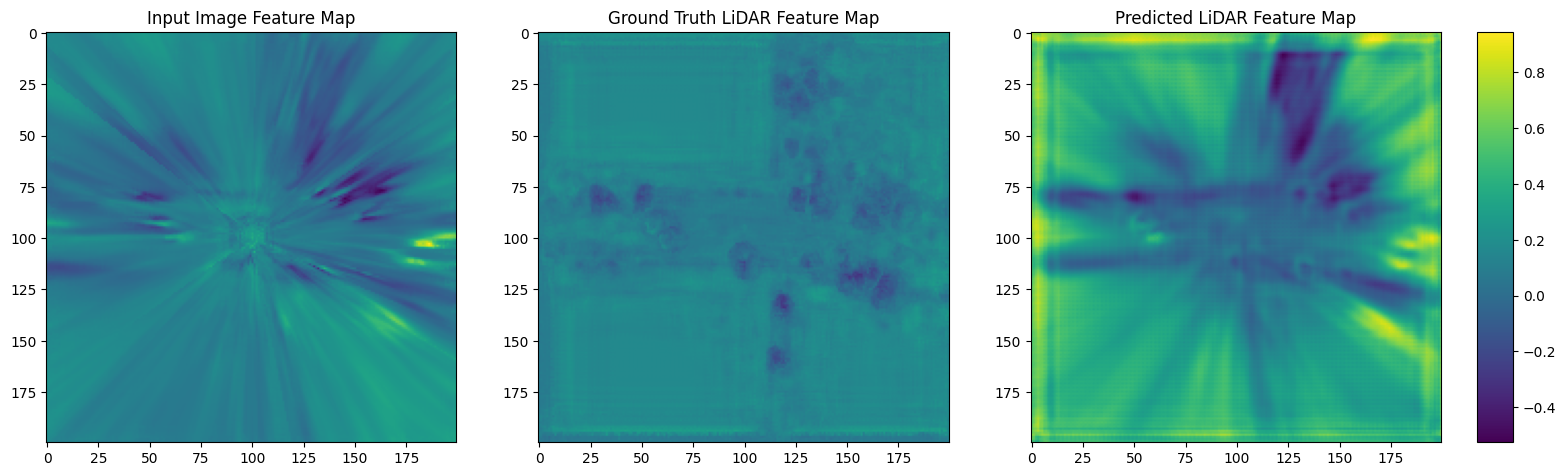

In [81]:
plot_train_pred_test(bvc_to_bchw(img_bev_embed)[0], bvc_to_bchw(pts_bev_embed)[0], y_pred_bchw[0], channel=8)

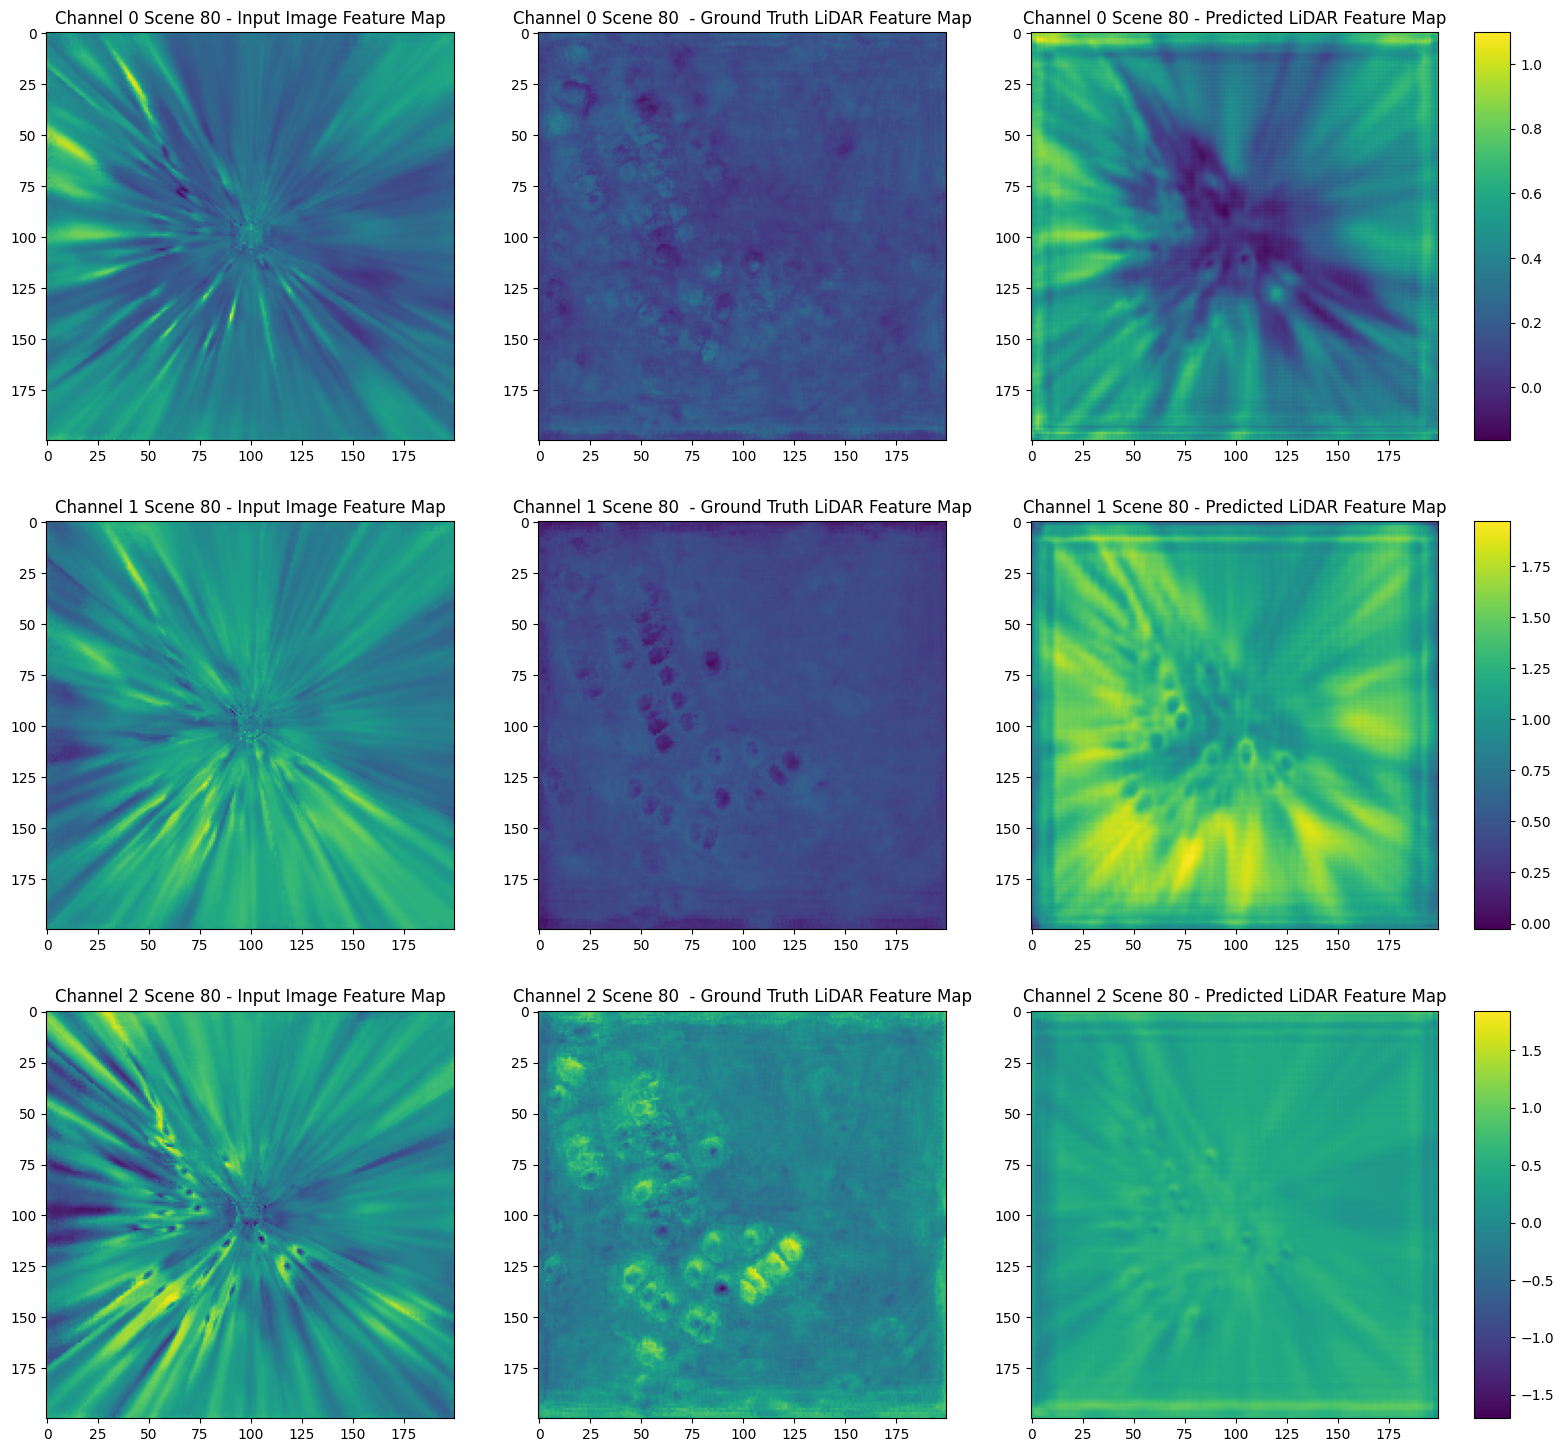

In [82]:
multiple_channels(bvc_to_bchw(img_bev_embed), bvc_to_bchw(pts_bev_embed), y_pred_bchw, channels=3, scene=80)